# ICS 2405: Knowledge-Based Systmes
## points in space: lines, planes and hyperplanes

### lines: cost for going to a concert:
`y = mx + b`

In [1]:
import numpy as np 
import pandas as pd
# import needed for 'projection':'3d'
from mpl_toolkits.mplot3d import Axes3D

from mlwpy import *
%matplotlib inline

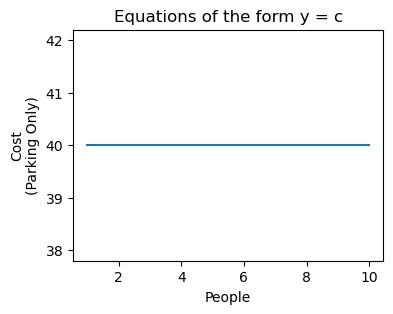

In [2]:
people = np.arange(1, 11)
# generates an array of ones with the same shape as people, resulting in [1, 1, 1, 1, 1, 1, 1, 1, 1, 1].
# x40.0 scales each element to 40.0
total_cost = np.ones_like(people) * 40.0 

ax = plt.gca() # get current axis from the active figure or create one
ax.plot(people, total_cost)

ax.set_title('Equations of the form y = c')
ax.set_xlabel("People")
ax.set_ylabel("Cost\n(Parking Only)");

# plot the cost of the form y = mx + b

In [3]:
people = np.arange(1, 11)
total_cost = 80.0 * people + 40.0
# .T (transpose) to save vertical space in printout
display(pd.DataFrame({'total_cost':total_cost.astype(int)},
index=people).T)

,1,2,3,4,5,6,7,8,9,10
total_cost,120,200,280,360,440,520,600,680,760,840


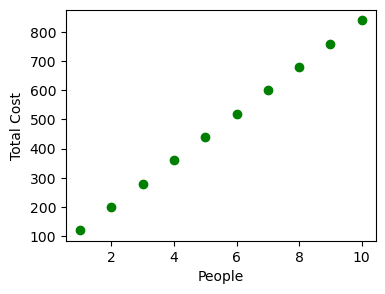

In [4]:
ax = plt.gca()
ax.plot(people, total_cost, 'go')
ax.set_ylabel("Total Cost")
ax.set_xlabel("People");

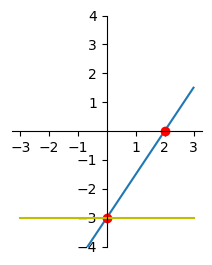

In [5]:
# paint by number
# create 100 x values from -3 to 3
xs = np.linspace(-3, 3, 100)
# slope (m) and intercept (b)
m, b = 1.5, -3
ax = plt.gca()
ys = m*xs + b
ax.plot(xs, ys)
ax.set_ylim(-4, 4)
high_school_style(ax) # helper from mlwpy.py
ax.plot(0, -3,'ro') # y-intercept
ax.plot(2, 0,'ro') # two steps right gives three steps up
# y = mx + b with m=0 gives y = b
ys = 0*xs + b
ax.plot(xs, ys, 'y')

In [6]:
# np.c_[] lets us create an array column-by-column
xs = np.linspace(-3, 3, 100)
xs_p1 = np.c_[xs, np.ones_like(xs)]
# view the first few rows
display(pd.DataFrame(xs_p1).head())

,0,1
0,-3.0000,1.0000
1,-2.9394,1.0000
2,-2.8788,1.0000
3,-2.8182,1.0000
4,-2.7576,1.0000


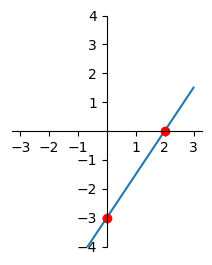

In [7]:
w = np.array([1.5, -3])
ys = np.dot(xs_p1, w)
ax = plt.gca()
ax.plot(xs, ys)
# styling
ax.set_ylim(-4, 4)
high_school_style(ax)

ax.plot(0, -3,'ro') # y-intercept
ax.plot(2, 0,'ro'); # two steps to the right should be three whole steps up

here are the two forms we used in the code: `ys = m*xs + b` and
`ys = np.dot(xs_p1, w)`. mathematically, these look like **y = mx + b** and **y = wx+**

### beyond lines: planes, hyperplanes

we can progress to wiggly curves and polynomials equations or we can go down the road to multiple dimensions:
planes, hyperplanes, etc for example, in `f(x, y, z) = x + y + z` we have multiple input values that we combine together. since we will be very interested in **multivariate data**—that’s multiple input

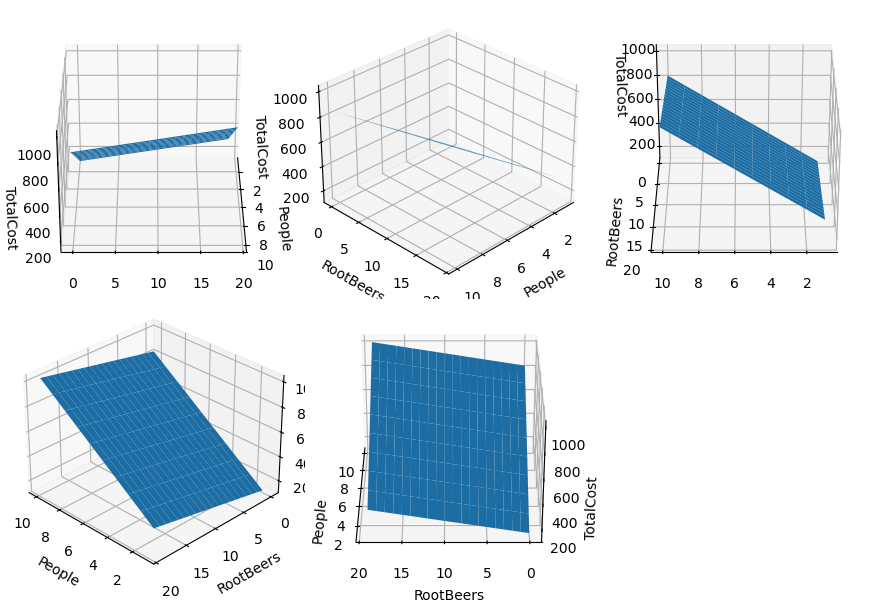

In [8]:
number_people = np.arange(1, 11) # 1-10 people
number_rbs = np.arange(0, 20) # 0-19 rootbeers
# numpy tool to get cross-product of values (each against each)
# in two paired arrays. try it out: np.meshgrid([0, 1], [10, 20])
# "perfect" for functions of multiple variables
number_people, number_rbs = np.meshgrid(number_people, number_rbs)
total_cost = 80 * number_people + 10 * number_rbs + 40

fig,axes = plt.subplots(2, 3,
subplot_kw={'projection':'3d'},
figsize=(9, 6))
angles = [0, 45, 90, 135, 180]
for ax, angle in zip(axes.flat, angles):
    ax.plot_surface(number_people, number_rbs, total_cost)
    ax.set_xlabel("People")
    ax.set_ylabel("RootBeers")
    ax.set_zlabel("TotalCost")
    ax.azim = angle

# we don't use the last axis
axes.flat[-1].axis('off')
fig.tight_layout()

straightforward, in code and in mathematics, to move beyond three
dimension

#### GOFT - make a table of the outcomes

In [9]:
number_people = np.array([2, 3])
number_rbs = np.array([0, 1, 2])
number_hotdogs = np.array([2, 4])
costs = np.array([80, 10, 5])
columns = ["People", "RootBeer", "HotDogs", "TotalCost"]

counts = np_cartesian_product(number_people, number_rbs, number_hotdogs)
totals = (costs[0] * counts[:, 0] + costs[1] * counts[:, 1] + costs[2] * counts[:, 2] + 40)
display(pd.DataFrame(np.c_[counts, totals], columns=columns).head(8))

,People,RootBeer,HotDogs,TotalCost
0,2,0,2,210
1,2,0,4,220
2,3,0,2,290
3,3,0,4,300
4,2,1,2,220
5,2,1,4,230
6,3,1,2,300
7,3,1,4,310


In [10]:
costs = np.array([80, 10, 5])
counts = np_cartesian_product(number_people, number_rbs, number_hotdogs)
totals = np.dot(counts, costs) + 40
display(pd.DataFrame(np.column_stack([counts, totals]),
columns=columns).head(8))

,People,RootBeer,HotDogs,TotalCost
0,2,0,2,210
1,2,0,4,220
2,3,0,2,290
3,3,0,4,300
4,2,1,2,220
5,2,1,4,230
6,3,1,2,300
7,3,1,4,310


here’s a detailed breakdown of what happened. first, we abstract by removing detailed variable names and then replacing our known values with generic identifiers:

$
y = 80x_3 + 10x_2 + 5x_1 + 40
$

This can be rewritten as:

$
y = w_3 x_3 + w_2 x_2 + w_1 x_1 + w_0 \cdot 1
$

next, we take this one step further in code by replacing the sums involving weights with a dot product:

$
y = \mathbf{w} \cdot \mathbf{x} + w_0 \cdot 1
$

the subscript $[3, 2, 1]$ on $\mathbf{w}$ indicates that we aren’t using all of the weights. namely, we are not using $w_0$ in the left-hand term. $w_0$ is included in the right-hand term, multiplying $1$. it is only being used once. the final coup de grâce is to perform the $+1$ trick:

$
y = \mathbf{w} \mathbf{x}^+
$

To summarize, instead of 

$
y = w_3 x_3 + w_2 x_2 + w_1 x_1 + w_0
$

we can write:

$
y = \mathbf{w} \mathbf{x}^+
$


In [11]:
# end